In [6]:
import torch
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt


In [8]:
#Compose is a pipeline as each image go through a process of 3 steps so instead of doing it anually we are wrapping it in object composer
transform = transforms.Compose([transforms.ToTensor(),
                              transforms.Normalize((0.1307,), (0.3081,))
                              ])




train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

In [15]:
#Dataloader breaks 60,000 imagedata into batch 64 so total 938 batches of size 64
train_loader = DataLoader(train_dataset, batch_size = 64, shuffle = True) #shuffling matters when you're learning from the order data is shown to you. It doesn't matter when you're just checking a final score.
test_loader = DataLoader(test_dataset, batch_size = 64, shuffle = False) 

In [16]:
#model architechture
model =  nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range (20):
    running_loss = 0.0



In [21]:
for data, targets in train_loader:
  optimizer.zero_grad()

  pred = model(data)
  print(pred.shape, targets.shape)

  loss = criterion(pred, targets)

  loss.backward()
  optimizer.step()

#it's the sum of ~938 separate loss values, one per batch, all added together.

  running_loss += loss.item()

running_loss /= len(train_loader)

print(f"Epoch {epoch+1}: {running_loss}" )

torch.Size([64, 10]) torch.Size([64])
torch.Size([64, 10]) torch.Size([64])
torch.Size([64, 10]) torch.Size([64])
torch.Size([64, 10]) torch.Size([64])
torch.Size([64, 10]) torch.Size([64])
torch.Size([64, 10]) torch.Size([64])
torch.Size([64, 10]) torch.Size([64])
torch.Size([64, 10]) torch.Size([64])
torch.Size([64, 10]) torch.Size([64])
torch.Size([64, 10]) torch.Size([64])
torch.Size([64, 10]) torch.Size([64])
torch.Size([64, 10]) torch.Size([64])
torch.Size([64, 10]) torch.Size([64])
torch.Size([64, 10]) torch.Size([64])
torch.Size([64, 10]) torch.Size([64])
torch.Size([64, 10]) torch.Size([64])
torch.Size([64, 10]) torch.Size([64])
torch.Size([64, 10]) torch.Size([64])
torch.Size([64, 10]) torch.Size([64])
torch.Size([64, 10]) torch.Size([64])
torch.Size([64, 10]) torch.Size([64])
torch.Size([64, 10]) torch.Size([64])
torch.Size([64, 10]) torch.Size([64])
torch.Size([64, 10]) torch.Size([64])
torch.Size([64, 10]) torch.Size([64])
torch.Size([64, 10]) torch.Size([64])
torch.Size([

In [22]:
model.eval()

test_loss = 0.0
correct = 0

samples = []   # first 10 test digits
misses = []    # first 10 the model got wrong


Test loss: 0.1088 | Accuracy: 96.45%
saved predictions.png
saved misclassified.png


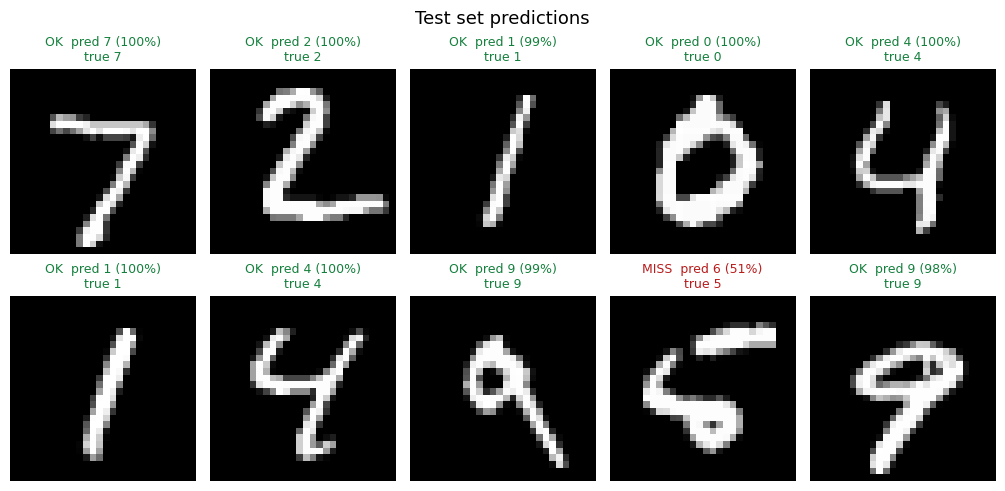

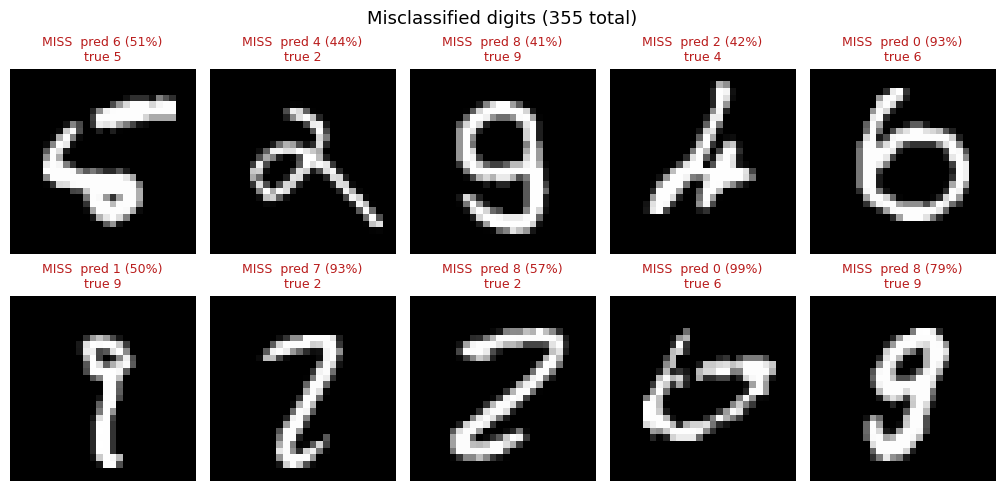

In [23]:
with torch.no_grad():         #, don't bother tracking gradients.
    for data, targets in test_loader:
        logits = model(data)
        test_loss += criterion(logits, targets).item()

        probs = F.softmax(logits, dim=1)          # only for display confidence
        conf, preds = probs.max(dim=1)
        correct += (preds == targets).sum().item()

        for i in range(len(data)):
            if len(samples) < 10:
                samples.append((data[i], targets[i].item(), preds[i].item(), conf[i].item()))
            if preds[i] != targets[i] and len(misses) < 10:
                misses.append((data[i], targets[i].item(), preds[i].item(), conf[i].item()))

test_loss /= len(test_loader)
accuracy = correct / len(test_dataset)

print(f"Test loss: {test_loss:.4f} | Accuracy: {accuracy:.2%}")


def show_digits(batch, title, filename):
    """Plot up to 10 (image, true, pred, confidence) tuples in a 2x5 grid."""
    if not batch:
        print(f"{title}: nothing to show")
        return

    fig, axes = plt.subplots(2, 5, figsize=(10, 4.8), constrained_layout=True)
    fig.suptitle(title, fontsize=13)

    for ax, (img, true, pred, conf) in zip(axes.ravel(), batch):
        ax.imshow(img.squeeze() * 0.3081 + 0.1307, cmap="gray")  # undo Normalize
        ok = pred == true
        ax.set_title(
            f"{'OK' if ok else 'MISS'}  pred {pred} ({conf:.0%})\ntrue {true}",
            fontsize=9,
            color="#15803d" if ok else "#b91c1c",
        )
        ax.axis("off")

    for ax in axes.ravel()[len(batch):]:   # blank any unused cells
        ax.axis("off")

    fig.savefig(filename, dpi=130)
    print(f"saved {filename}")


show_digits(samples, "Test set predictions", "predictions.png")
show_digits(misses, f"Misclassified digits ({len(test_dataset) - correct} total)", "misclassified.png")
plt.show()